In [58]:
import os
import caesar
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import modules as anal
import modules.anal_func as anal_func

from astropy.cosmology import LambdaCDM
import astropy.units as u
from astropy.io import fits
from scipy import interpolate

from modules.anal_func.build_history import BuildHistory
from modules.anal_func.read_progenitors import read_progen

from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


cosmo = LambdaCDM(H0 = 68, Om0= 0.3, Ode0= 0.7, Ob0=0.048)
plt.rcParams.update({'font.size': 28})

In [59]:
# initialize the Simba class, which import the needed paths
sb = anal.Simba('PC39BP4', size=100)
# initialize the SavePaths class to create destinations
sv = anal.SavePaths() 
pltsv  = sv.get_filetype_path('plot')
scatter = sv.create_subdir(pltsv, 'scatter')

In [63]:
cs = sb.get_caesar(148)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sfh = BuildHistory(sb, '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', progfilename='progenitors_recursive.fits') #'progenitors_recursive.fits') #'progenitors_most_mass_nocaesar.fits')

yt : [INFO     ] 2025-06-15 15:15:00,654 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_148.hdf5
yt : [INFO     ] 2025-06-15 15:15:00,662 Found 467847 halos
yt : [INFO     ] 2025-06-15 15:15:00,665 Found 54406 galaxies


In [65]:
hist = sfh.get_history_indx(totids[:], start_snap=150, end_snap=45)

In [66]:
positions = sfh.get_property_history(['pos_0', 'pos_1' , 'pos_2', 'GroupID', 'sfr', 'stellar_masses'])

Number of snapshots: 106
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_150.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_149.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_148.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_147.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_146.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_145.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_144.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_143.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_142.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_141.fits
Opening /home/lorenzong/analize_simba_cgm/out

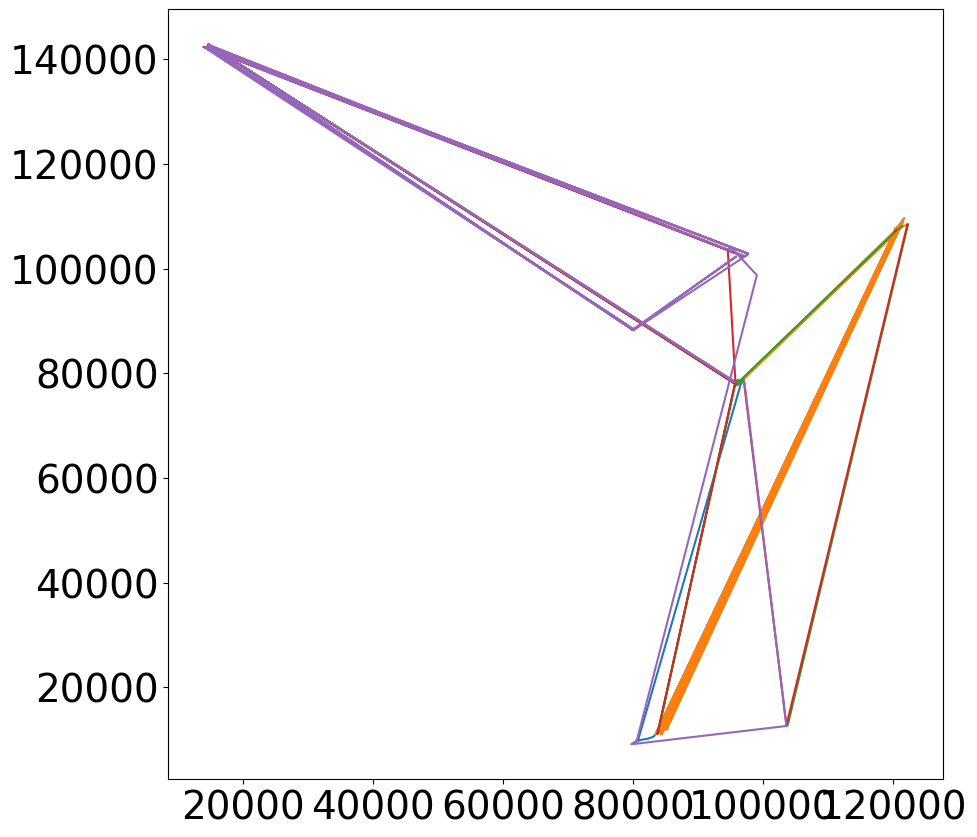

In [68]:
plt.figure(figsize=(10, 10))
for i in range(len(positions['pos_0'][:5])):
    plt.plot(positions['pos_0'][:,i], positions['pos_1'][:,i])

In [33]:
for i in totids:
    a = np.all(positions['pos_0'][:,0] == positions['pos_0'][:,i])
    if a:
        print(i, a)


0 True
4054 True
24568 True
25993 True
27298 True
28691 True
28808 True
29823 True
29925 True
30212 True
30627 True
30671 True
31204 True
31244 True
31479 True
31941 True
32478 True
33157 True
33338 True
33425 True
33934 True
33978 True
34012 True
34275 True
34298 True
34337 True
34396 True
34736 True
34972 True
35113 True
35213 True
35765 True
35775 True
35944 True
36207 True
36326 True
36811 True
36903 True
37174 True
37306 True
37332 True
37636 True
37754 True
37838 True
37899 True
37933 True
38048 True
38117 True
38644 True
38729 True
38831 True
38850 True
38891 True
38946 True
39182 True
39202 True
39311 True
39365 True
39736 True
39811 True
39947 True
39951 True
40010 True
40042 True
40145 True
40270 True
40409 True
40438 True
40565 True
40569 True
40691 True
40964 True
40979 True
41298 True
41469 True
41636 True
41799 True
41810 True
41880 True
41902 True
41909 True
42065 True
42137 True
42175 True
42217 True
42486 True
42493 True
42554 True
42632 True
42644 True
42657 True
4270

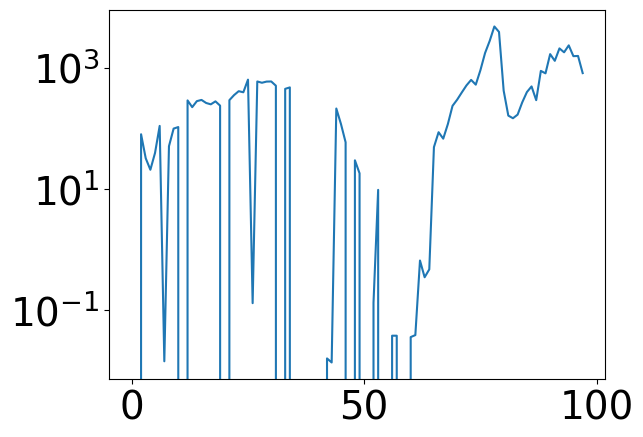

In [45]:
plt.plot(positions['sfr'][:,0])
plt.yscale('log')

In [ ]:
# define our redshift range
z = sb.get_z_from_snap(np.arange(44, 150, 1))
tcosmo = cosmo.age(z).value

indx = -16
print('z = ', z[indx])
print(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), 'Gyr')

In [ ]:
# Specific SFR selection
ssfr = np.log10(positions['sfr'][indx, :] / positions['stellar_masses'][indx, :])
ssfr_cut = ssfr < np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value)
galaxy_selection = np.where(ssfr_cut)[0]
print(f"Number of galaxies selected: {len(galaxy_selection)} over {len(positions['stellar_masses'][indx, :])} total galaxies.")


In [ ]:
import numpy as np

def find_mergers(gal_data, target_ids, indx, z, distance_thresh=0.1, min_consecutive=2):
    """
    Identify potential mergers based on 3D proximity over consecutive snapshots.
    
    Parameters
    ----------
    gal_data : dict
        Dictionary with keys 'pos_x', 'pos_y', 'pos_z', and 'GroupID'.
    target_ids : array-like
        GroupIDs of target galaxies to analyze.
    distance_thresh : float
        Distance threshold in Mpc (default 0.1 = 100 kpc).
    min_consecutive : int
        Minimum number of consecutive snapshots for a close passage.
    
    Returns
    -------
    mergers : dict
        Dictionary mapping each target GroupID to a set of merging GroupIDs.
    """
    pos_x = np.array(gal_data['pos_0'])  # shape (n_snap, n_gal)
    pos_y = np.array(gal_data['pos_1'])
    pos_z = np.array(gal_data['pos_2'])
    group_ids = np.array(gal_data['GroupID']).astype(int)  # shape (n_gal,)
    
    n_snap, n_gal = pos_x.shape
    positions = np.stack([pos_x, pos_y, pos_z], axis=2)  # shape (n_snap, n_gal, 3)
    
    mergers = {}

    # Find indices of target galaxies
    target_mask = np.isin(group_ids[indx, :], target_ids)
    target_indices = np.where(target_mask)[0]
    print(target_indices)
    print(f"Found {len(target_indices)} target galaxies in snapshot {indx}.")
    for tgt_idx in target_indices:
        print(f"Processing target galaxy {group_ids[indx, tgt_idx]} at index {tgt_idx}...")
        tgt_id = group_ids[indx, tgt_idx]
        tgt_pos = positions[:, tgt_idx, :]  # shape (n_snap, 3)

        # Compute 3D distances to all galaxies across snapshots
        dist = np.linalg.norm(positions - tgt_pos[:, np.newaxis, :], axis=2)*0.68  # (n_snap, n_gal)


        # Apply distance threshold (exclude self)
        close_mask = (dist < distance_thresh)
        close_mask[:, tgt_idx] = False  # remove self-match

        # Track galaxies that are within threshold for ≥min_consecutive snapshots
        potential_mergers = set()
        for gal_idx in range(n_gal):
            close_snapshots = close_mask[:, gal_idx]
            # Check for ≥2 consecutive Trues
            if np.any(np.convolve(close_snapshots.astype(int), np.ones(min_consecutive, dtype=int), mode='valid') >= min_consecutive):
                potential_mergers.add(group_ids[indx, gal_idx])
                #print(f"Found potential merger: {group_ids[indx, gal_idx]}")

        mergers[tgt_id] = potential_mergers

    return mergers


In [ ]:
merger_dict = find_mergers(positions, positions['GroupID'][-1, galaxy_selection][:3], 0, z, distance_thresh=100, min_consecutive=4)


In [ ]:
merger_dict.keys()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:30]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    # Plot their positions over time
    plt.figure(figsize=(12, 12))
    for idx in indices:
        plt.plot(pos_x[:, idx], pos_y[:, idx], marker='o', markersize=2, label=f'ID {group_ids[-1, idx]}')
        plt.scatter(pos_x[0, idx], pos_y[0, idx], s=100, label=f'Start Position ID {group_ids[-1, idx]}', edgecolor='black')
    
    plt.xlabel('X [cMpc]')
    plt.ylabel('Y [cMpc]')
    plt.title(f'Galaxy {tgt_id} and Merger Companions (Trajectories)')
    plt.tight_layout()
    plt.show()


In [ ]:
def find_disrupted_galaxies(positions, merger_dict, group_ids):
    pos_x = positions['pos_0']  # shape (n_snap, n_gal)
    n_snap, n_gal = pos_x.shape

    disrupted_info = {}  # key: main galaxy ID, value: list of dicts for disrupted galaxies

    for main_id, candidate_ids in merger_dict.items():
        disrupted_info[main_id] = []
        print(f"Processing main galaxy {main_id} with {len(candidate_ids)} candidates...")

        for cid in candidate_ids:
            # Get index of this candidate galaxy
            try:
                idx = np.where(group_ids == cid)[0][0]
            except IndexError:
                continue  # GroupID not found in last snapshot

            # Track whether the galaxy was alive and when it disappeared
            pos_time_series = pos_x[:, idx]
            not_nan_mask = ~np.isnan(pos_time_series)

            if np.any(not_nan_mask):
                first_nan_after_real = np.where((~not_nan_mask[:-1]) & not_nan_mask[1:])[0]
                # Better logic: find the **first index where it becomes NaN after being real**
                last_real_idx = np.where(not_nan_mask)[0][-1]
                if last_real_idx < n_snap - 1:
                    # Galaxy is gone after last_real_idx
                    snapshot_disrupted = last_real_idx + 1  # first NaN
                    disrupted_info[main_id].append({
                        'id': cid,
                        'disrupted_at': snapshot_disrupted,
                        'index': idx
                    })

    return disrupted_info


In [ ]:
disrupted_info = find_disrupted_galaxies(positions, merger_dict, positions['GroupID'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:3]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    for idx in indices:
        print(pos_x[-1, idx])

    



In [ ]:
positions['pos_0'][:, 10]

In [ ]:
target_mask = np.isin(positions['GroupID'][indx, :], positions['GroupID'][indx, galaxy_selection][:3])
print(target_mask, len(target_mask), positions['GroupID'][indx, :][target_mask])

In [ ]:
plt.plot(positions['GroupID'][indx, :])

In [ ]:

unique_elements, counts = np.unique(positions['GroupID'][-2, :], return_counts=True)

# Now you have:
# - unique_elements: the unique values in the array
# - counts: how many times each unique value appears

# Example: print as dictionary
count_dict = dict(zip(unique_elements, counts))
print(count_dict)

In [ ]:
import numpy as np
import h5py
from astropy.io import fits

def build_progenitor_groupid_table(simba_obj, snaplist, output_fits, base_snap=151):
    """
    Build a progenitor table: each row corresponds to a galaxy in base_snap,
    and each column gives the GroupID of its main progenitor at that snapshot.
    """
    snaplist = sorted(snaplist, reverse=True)
    print(f'The base snap is {snaplist[0]}')  # descending order
    #if base_snap != snaplist[0]:
    #    raise ValueError("base_snap must be the first snapshot in snaplist")

    print(f"Tracking progenitors from snapshot {base_snap} back to {snaplist[-1]}")
    columns = []
    for si, snap in enumerate(snaplist):
        fpath = simba_obj.get_caesar_file(snap)
        
        with h5py.File(fpath, 'r') as f:
            if si == 0:
                print(f"Processing snapshot {fpath}...")
                print(f"Reading progenitor data from the first snapshot {snap}...")
                prevprog = np.array(f['tree_data']['progen_galaxy_star'][:,0])
                current_indices = np.array(f['galaxy_data']['GroupID'])
                prog_table = np.full((len(current_indices), len(snaplist)), -1, dtype=int)
                valid = np.where(prevprog >= 0)[0]
                prevprog = prevprog[valid]
                print('ID: ,', current_indices)
                print('Progenitor IDs:', prevprog)
                print('=========================================================================')
                
            else:
                print(f"Processing snapshot {fpath}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'])[prevprog][:, 0]
                current_indices = np.array(f['galaxy_data']['GroupID'])
                print('ID: ,', current_indices)
                print('Progenitor IDs:', prevprog)
                valid = np.where(progenid >= 0)[0]
                progenid = progenid[valid]
                
                
            temp = current_indices[prevprog]
            prog_table[prevprog, si] = temp
            print(prog_table[prevprog, si])
            print('=========================================================================')
            if si !=0:
                prevprog = progenid
            


    # Write to FITS file
    for si, snap in enumerate(snaplist):
        columns.append(fits.Column(name=f'{snap}', format='K', array=prog_table[:, si]))
        
               

    hdu = fits.BinTableHDU.from_columns(columns)
    hdu.writeto(output_fits, overwrite=True)
    print(f"Saved progenitor GroupID table to {output_fits}")


In [74]:
from modules.io_paths import SavePaths
import h5py
sb = anal.Simba('PC39BP4', size=100)
snaplist = list(range(151, 44, -1))  # or whatever range you need
paths = SavePaths()
outdir = paths.create_subdir(paths.get_filetype_path('fits'), 'progenitors_files')
output_fits = os.path.join(outdir, 'progenitors_recursive.fits')

build_progenitor_groupid_table(sb, snaplist, output_fits)


The base snap is 151
Tracking progenitors from snapshot 151 back to 45
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_151.hdf5...
Reading progenitor data from the first snapshot 151...
ID: , [    0     1     2 ... 55606 55607 55608]
Progenitor IDs: [    0     1     2 ... 55257 54582 50133]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_150.hdf5...
ID: , [    0     1     2 ... 55333 55334 55335]
Progenitor IDs: [    0     1     2 ... 55257 54582 50133]
[-1 -1 -1 ... -1 -1 -1]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_149.hdf5...
ID: , [    0     1     2 ... 55058 55059 55060]
Progenitor IDs: [    0     1     2 ... 52407 50861 53237]
[-1 -1 -1 ... -1 -1 -1]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_148.hdf5...
ID: , [    0     1     2 ... 54403 54404 54405]
Progenitor IDs: [    0     1     2 ... 54402 51616 53745]
[-1 -1 -1 ... -1 -1 -1]
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/

In [53]:
a = np.array([1, 2, 3, 4, 5])
b = a[[3,2,3,0,1]]
print(b)  # Output: [4 3 4 1 2]

[4 3 4 1 2]


In [74]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

def plot_xy_progenitor_paths(fits_x, fits_y, row_indices=None, label_rows=True):
    # Load FITS files
    with fits.open(fits_x) as hdul_x, fits.open(fits_y) as hdul_y:
        data_x = hdul_x[1].data
        data_y = hdul_y[1].data
        colnames_x = hdul_x[1].columns.names
        colnames_y = hdul_y[1].columns.names

    # Sanity check: same column names
    if set(colnames_x) != set(colnames_y):
        raise ValueError("The x and y FITS files must have the same column names (snapshots).")

    # Sort by snapshot number
    try:
        snaps = np.array([int(c) for c in colnames_x])
    except ValueError:
        raise ValueError("Snapshot column names must be integers (e.g. 151, 150, ...)")

    sort_idx = np.argsort(snaps)
    snaps = snaps[sort_idx]
    sorted_cols = [colnames_x[i] for i in sort_idx]

    # Convert tables to arrays (shape: ngalaxies × nsnapshots)
    x_vals = np.vstack([data_x[col] for col in sorted_cols]).T
    y_vals = np.vstack([data_y[col] for col in sorted_cols]).T

    if row_indices is None:
        row_indices = [0]  # default: first row only

    # Plot
    plt.figure(figsize=(7, 7))
    for i in row_indices:
        plt.plot(x_vals[i], y_vals[i], marker='o', label=f"Galaxy {i}" if label_rows else None)

    plt.xlabel("X [kpc]")
    plt.ylabel("Y [kpc]")
    plt.title("Progenitor X–Y Trajectories")
    if label_rows:
        plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


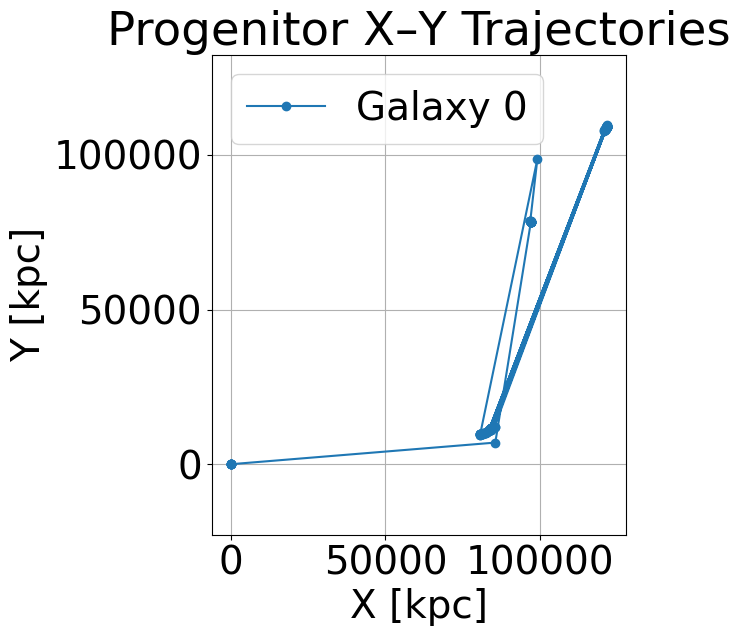

In [75]:
plot_xy_progenitor_paths('/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive_0.fits', '/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive_1.fits')


In [91]:
f = h5py.File('/media/lorenzong/Data1/SIMBA_catalogs/m100n1024_045.hdf5', 'r')
groupids = f['galaxy_data']['GroupID'][:]
np.all(groupids == np.arange(len(groupids)))


True

In [11]:
from modules.anal_func import read_progenitors
read_progenitors.read_descendants_using_groupid([0,1,2,3,4], np.arange(45, 149),
                                                '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', sb,
                                                '/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/miarrendo.fits')

Reading snapshot 148: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_148.fits
Reading snapshot 147: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_147.fits
Reading snapshot 146: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_146.fits
Reading snapshot 145: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_145.fits
Reading snapshot 144: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_144.fits
Reading snapshot 143: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_143.fits
Reading snapshot 142: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_142.fits
Reading snapshot 141: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_141.fits
Reading snapshot 140: /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_140.fits
Reading snapshot 139: /home/lorenzong